# Phase 2 — EDA / Visualisation

This notebook uses the cleaned data and documents plot-level takeaways.


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

clean_path = "dcs_student_data_cleaned.csv"
raw_path = "dcs_student_data.csv"

if pd.io.common.file_exists(clean_path):
    df = pd.read_csv(clean_path)
    source = clean_path
else:
    df = pd.read_csv(raw_path)

    score_columns = [
        "Attendance (%)",
        "Midterm_Score",
        "Final_Score",
        "Assignments_Avg",
        "Quizzes_Avg",
        "Participation_Score",
        "Projects_Score",
        "Total_Score",
        "math_score",
        "reading_score",
        "writing_score",
        "science_score",
    ]

    for col in score_columns + ["Age"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    dept_map = {
        "engineering": "Engineering",
        "business": "Business",
        "mathematics": "Mathematics",
        "math": "Mathematics",
        "computer science": "Computer Science",
        "cs": "Computer Science",
    }
    df["Gender"] = df["Gender"].astype(str).str.strip().str.lower().map({
        "female": "Female",
        "male": "Male",
    }).fillna(df["Gender"].astype(str).str.strip().str.title())
    df["Department"] = (
        df["Department"].astype(str).str.strip().str.lower().map(dept_map)
        .fillna(df["Department"].astype(str).str.strip().str.title())
    )

    for col in score_columns:
        df.loc[(df[col] < 0) | (df[col] > 100), col] = np.nan
    df.loc[(df["Age"] < 15) | (df["Age"] > 60), "Age"] = np.nan
    df = df.drop_duplicates(subset=["Student_ID"], keep="first").copy()

    source = raw_path + " (cleaned in notebook)"

print(f"Loaded data source: {source}")
print(f"Shape used for EDA: {df.shape}")


Loaded data source: dcs_student_data_cleaned.csv
Shape used for EDA: (10000, 21)


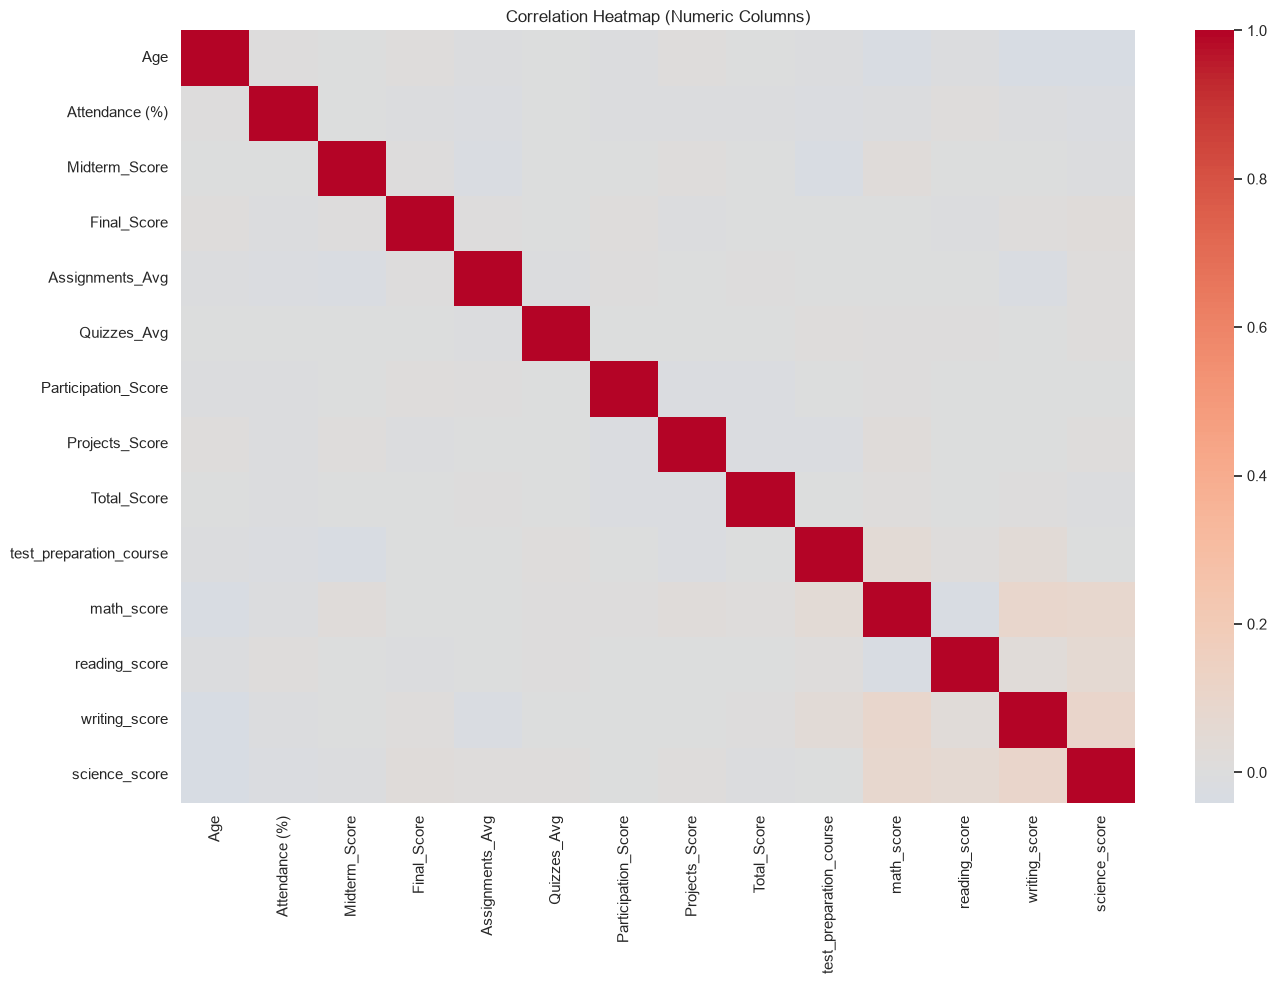

In [2]:
numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
plt.figure(figsize=(14, 10))
sns.heatmap(df[numeric_cols].corr(), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (Numeric Columns)")
plt.tight_layout()
plt.show()


**Takeaway:** Most correlations are near zero, indicating little to no predictive linear signal between features and overall scores in this dataset.


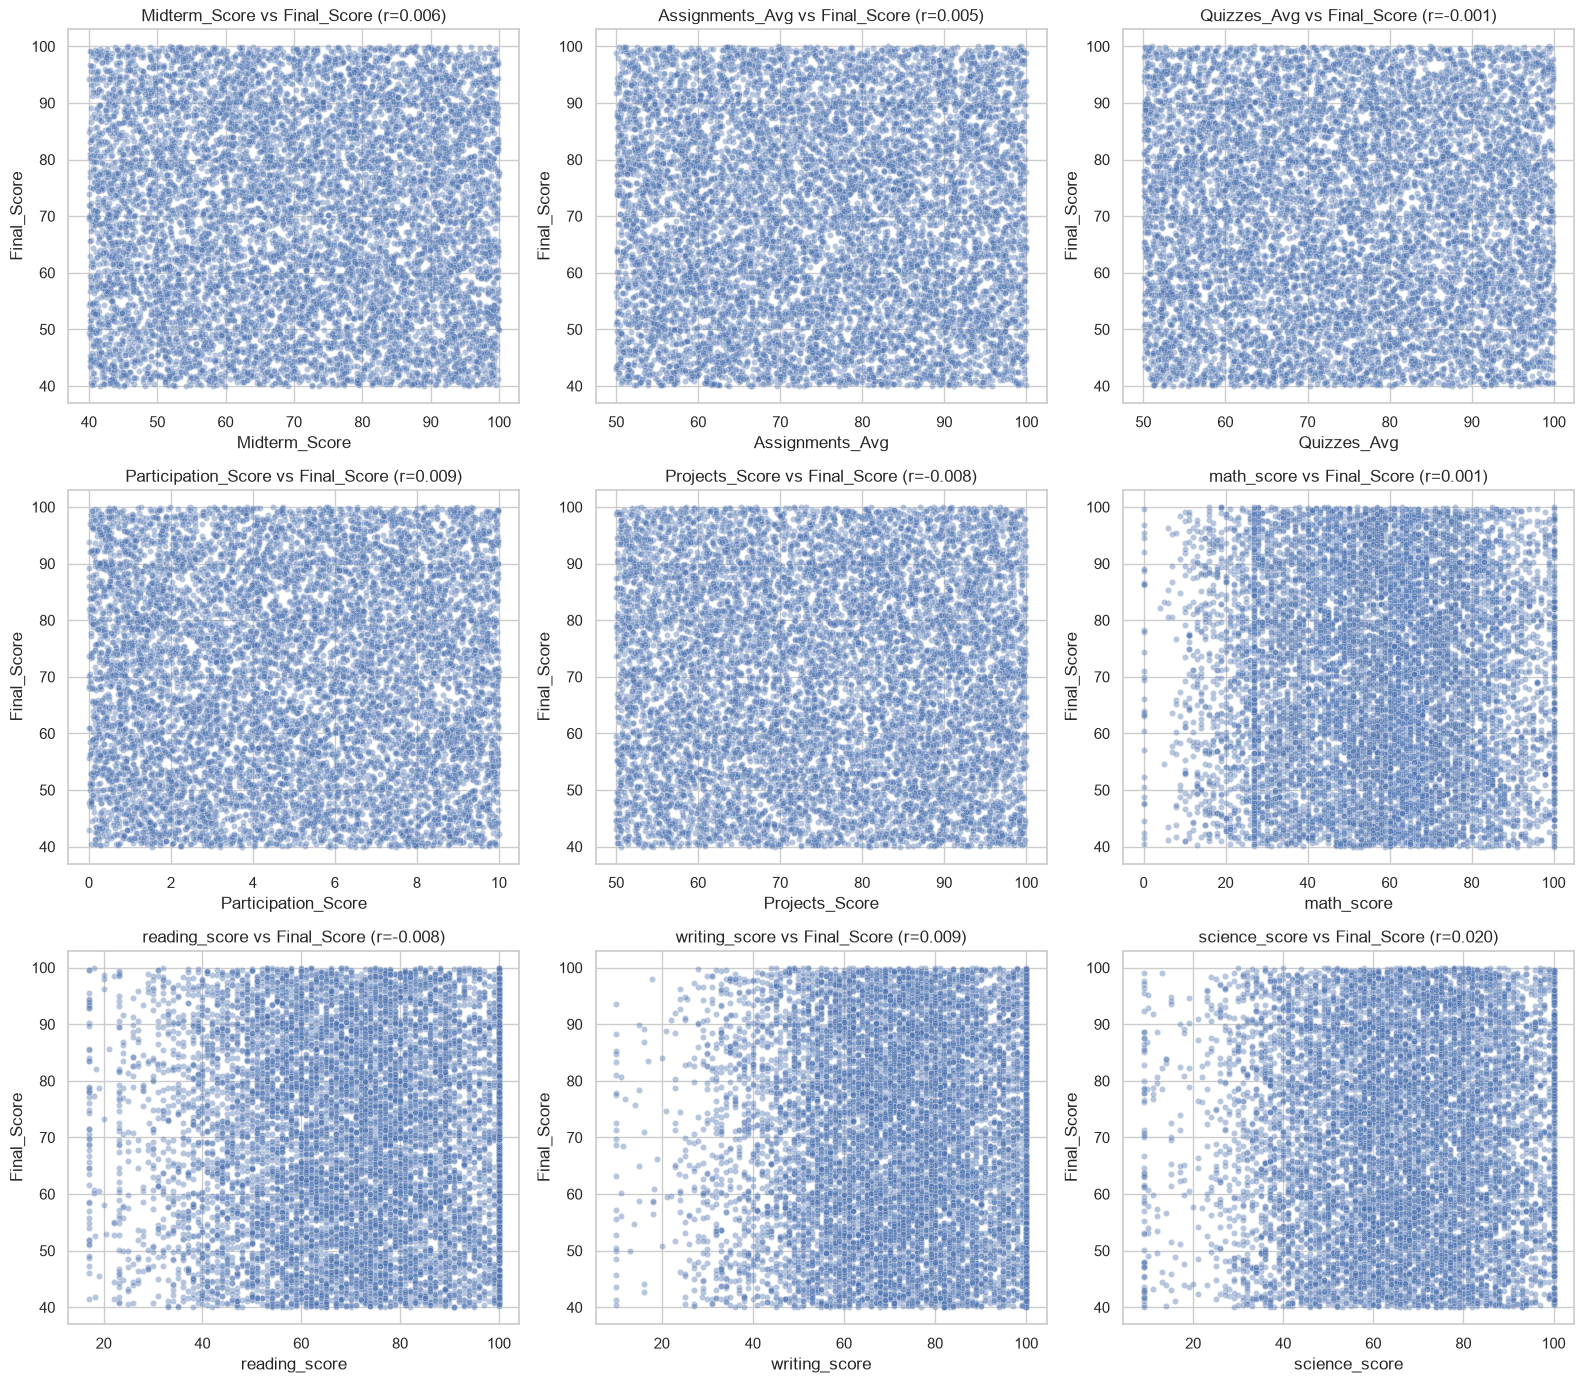

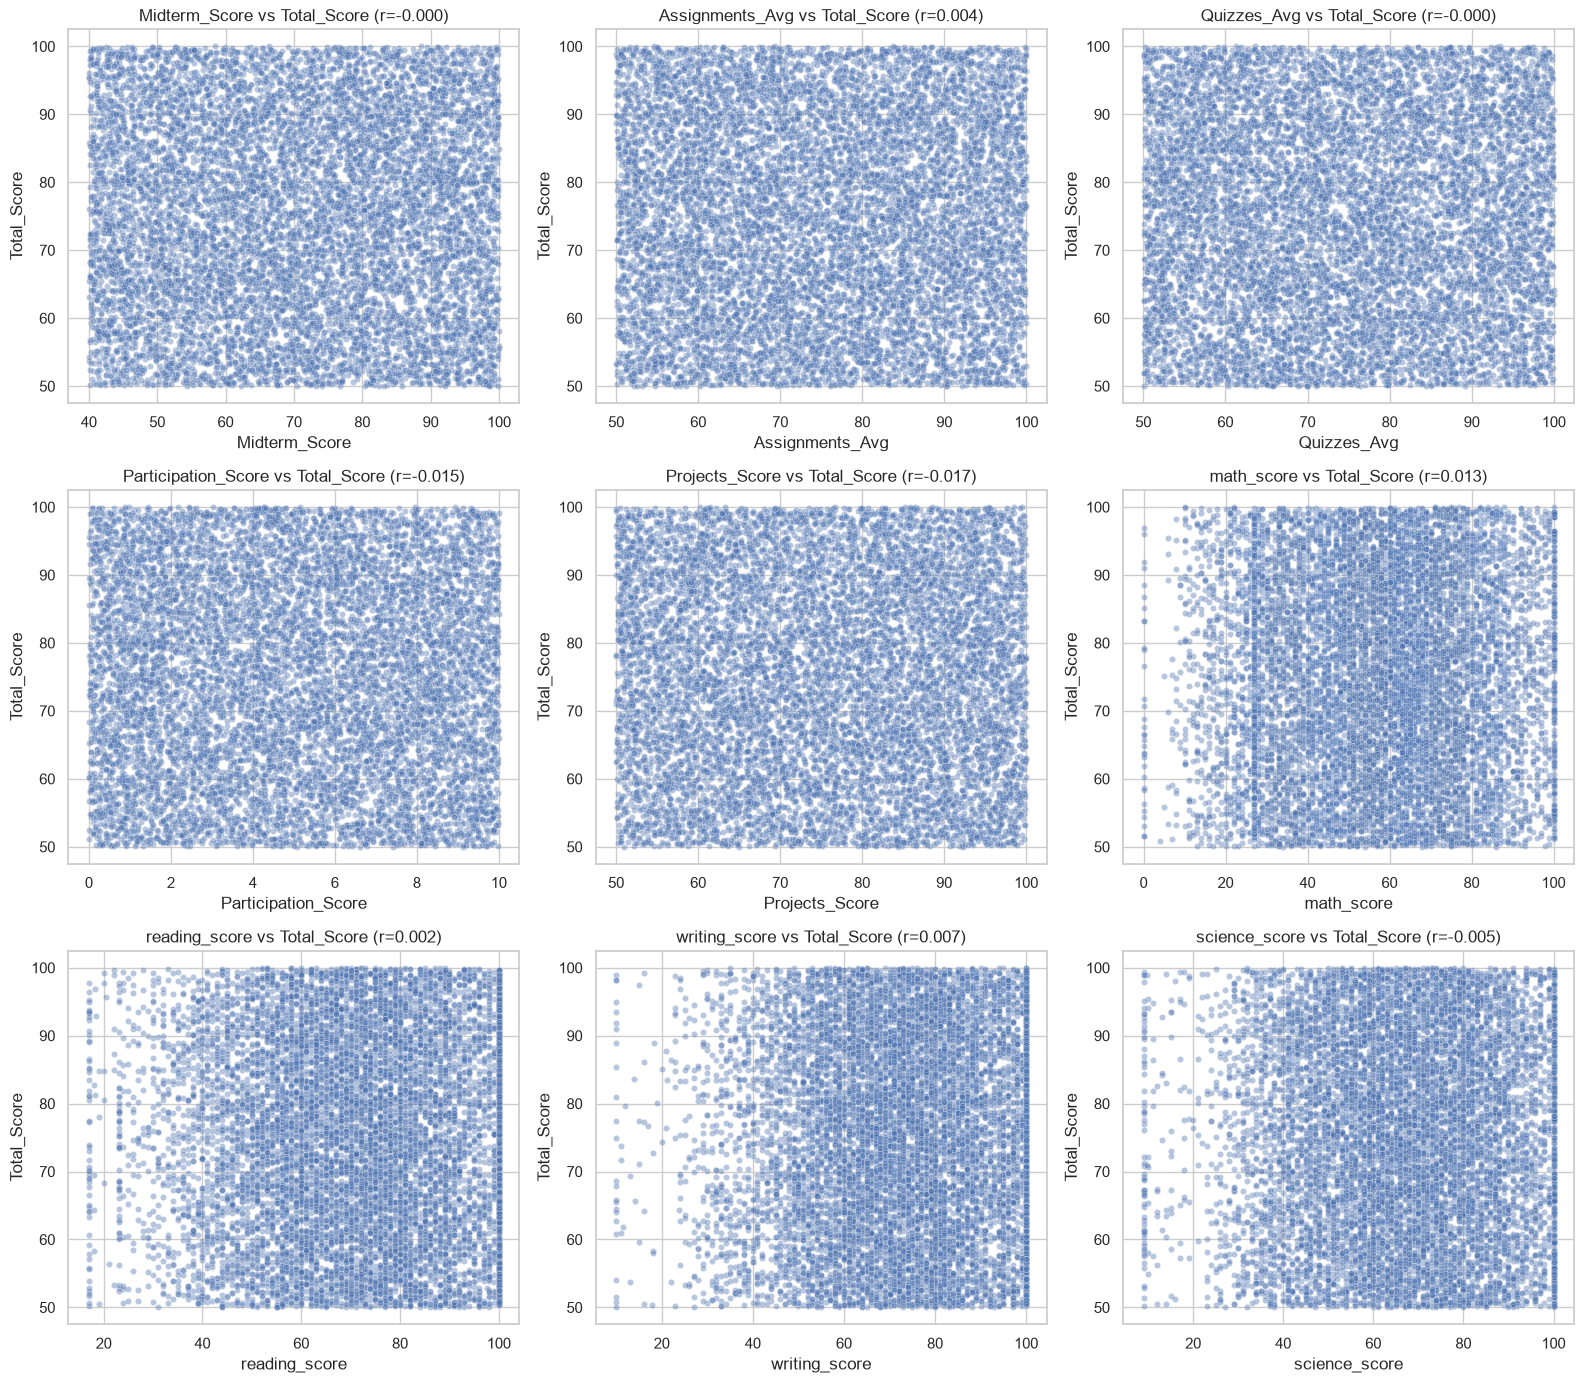

In [3]:
score_columns = [
    "Midterm_Score",
    "Assignments_Avg",
    "Quizzes_Avg",
    "Participation_Score",
    "Projects_Score",
    "math_score",
    "reading_score",
    "writing_score",
    "science_score",
]

for target in ["Final_Score", "Total_Score"]:
    fig, axes = plt.subplots(3, 3, figsize=(16, 14))
    axes = axes.flatten()

    for ax, col in zip(axes, score_columns):
        sns.scatterplot(data=df, x=col, y=target, alpha=0.4, s=20, ax=ax)
        corr = df[[col, target]].corr().iloc[0, 1]
        ax.set_title(f"{col} vs {target} (r={corr:.3f})")

    plt.tight_layout()
    plt.show()


**Takeaway:** Scatter plots remain diffuse across all feature-score pairs, and the correlation values are close to zero for most relationships.


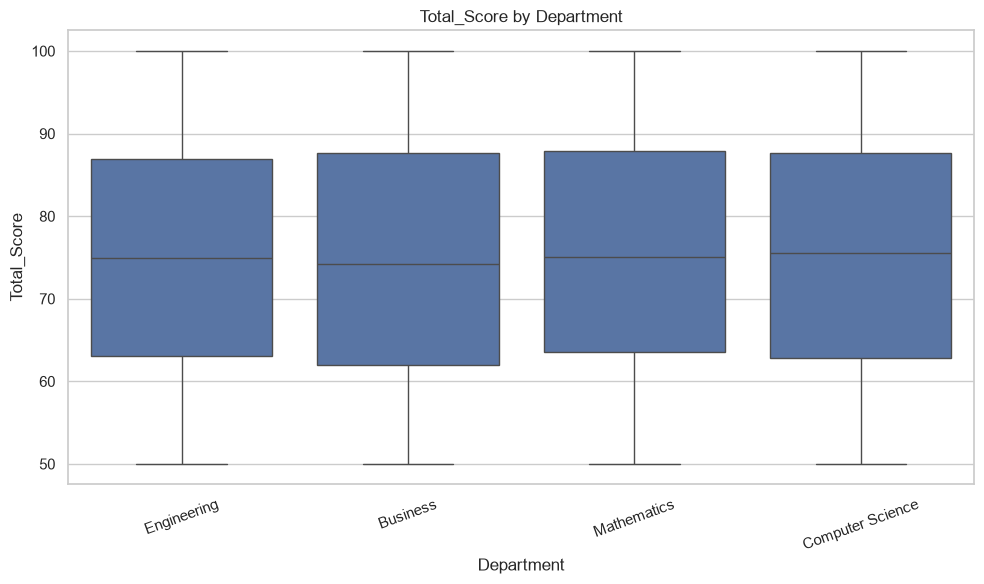

In [4]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="Department", y="Total_Score")
plt.xticks(rotation=20)
plt.title("Total_Score by Department")
plt.tight_layout()
plt.show()


**Takeaway:** Department-level score distributions overlap heavily, with no strong separation in medians or spread.


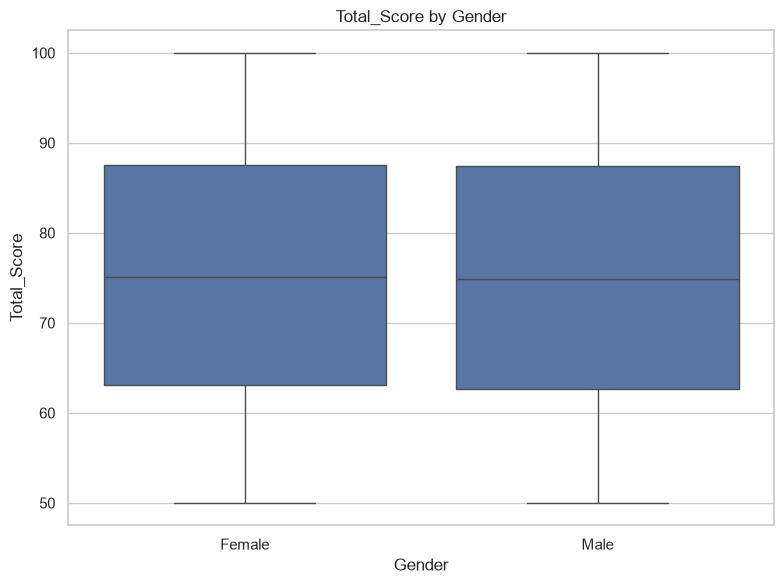

In [5]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x="Gender", y="Total_Score")
plt.title("Total_Score by Gender")
plt.tight_layout()
plt.show()


**Takeaway:** Gender groups show very similar score distributions, suggesting no meaningful difference by gender in this dataset.


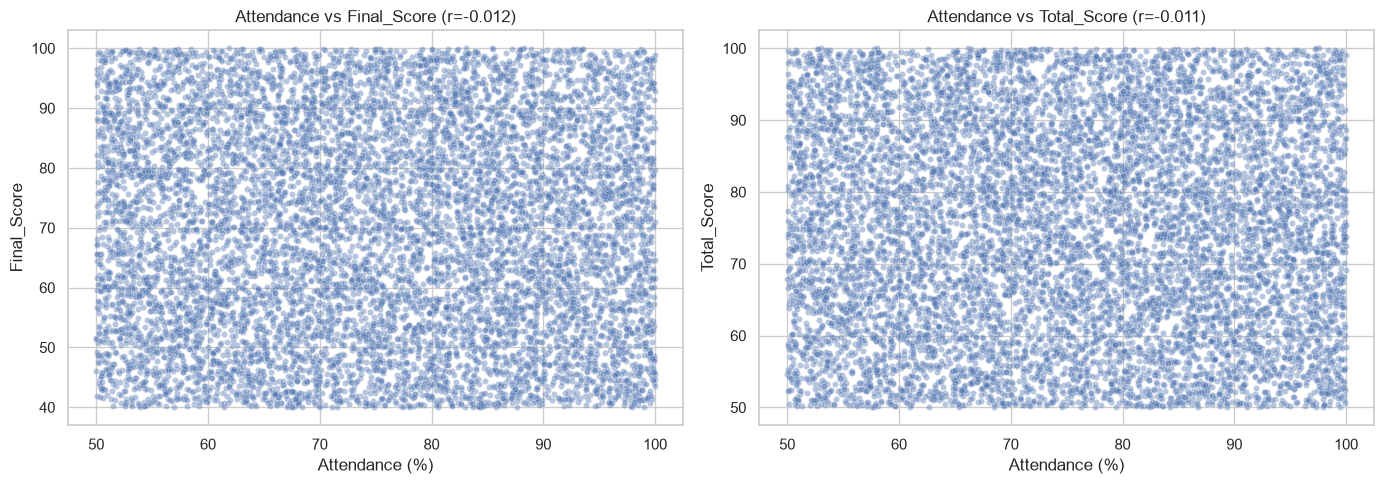

Attendance vs Final_Score correlation: -0.012
Attendance vs Total_Score correlation: -0.011


In [6]:
attendance_final_corr = df[["Attendance (%)", "Final_Score"]].corr().iloc[0, 1]
attendance_total_corr = df[["Attendance (%)", "Total_Score"]].corr().iloc[0, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=df, x="Attendance (%)", y="Final_Score", alpha=0.4, s=20, ax=axes[0])
axes[0].set_title(f"Attendance vs Final_Score (r={attendance_final_corr:.3f})")

sns.scatterplot(data=df, x="Attendance (%)", y="Total_Score", alpha=0.4, s=20, ax=axes[1])
axes[1].set_title(f"Attendance vs Total_Score (r={attendance_total_corr:.3f})")

plt.tight_layout()
plt.show()

print(f"Attendance vs Final_Score correlation: {attendance_final_corr:.3f}")
print(f"Attendance vs Total_Score correlation: {attendance_total_corr:.3f}")


**Takeaway:** Attendance has near-zero correlation with both Final_Score and Total_Score in this data, so it does not appear to explain performance variation.


## Final EDA Conclusion

The heatmap and all scatter/box plots consistently show a **no-signal pattern**: variables are largely independent with weak correlations and overlapping distributions, so strong predictive performance should not be expected from these inputs.


## Phase 3 — Define risk criteria

**Risk rule (justified):**
- **High:** Total_Score < 60
- **Medium:** 60 ≤ Total_Score < 75
- **Low:** Total_Score ≥ 75

This thresholding is transparent and matches the project objective of triaging students by overall academic performance. Attendance is kept for recommendation context but excluded from model features due the no-signal EDA finding.


In [7]:
def assign_risk(total_score):
    if pd.isna(total_score):
        return np.nan
    if total_score < 60:
        return "High"
    if total_score < 75:
        return "Medium"
    return "Low"


df["Risk"] = df["Total_Score"].apply(assign_risk)

print("Risk class distribution:")
print(df["Risk"].value_counts(dropna=False))


Risk class distribution:
Risk
Low       5010
Medium    3035
High      1955
Name: count, dtype: int64


**Takeaway:** The `Risk` label is now explicitly defined and reproducible, which is critical for consistent downstream modeling and recommendation behavior.


## Phase 4 — Fill missing values and split


In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier

feature_cols = [
    "Midterm_Score",
    "Assignments_Avg",
    "Quizzes_Avg",
    "Participation_Score",
    "Projects_Score",
    "math_score",
    "reading_score",
    "writing_score",
    "science_score",
    "test_preparation_course",
    "Department",
    "Gender",
]

numeric_features = [
    "Midterm_Score",
    "Assignments_Avg",
    "Quizzes_Avg",
    "Participation_Score",
    "Projects_Score",
    "math_score",
    "reading_score",
    "writing_score",
    "science_score",
]
categorical_features = ["test_preparation_course", "Department", "Gender"]

model_df = df[df["Risk"].notna()].copy()
X = model_df[feature_cols]
y = model_df["Risk"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Rows used for supervised modeling: {len(model_df)}")
print(f"Train shape: {X_train.shape} | Test shape: {X_test.shape}")


Rows used for supervised modeling: 10000
Train shape: (8000, 12) | Test shape: (2000, 12)


**Takeaway:** Missing values are handled via median (numeric) and most-frequent (categorical) imputation inside the model pipeline, and the class ratio is preserved by stratified splitting.


## Phase 5 — Model training


In [9]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(steps=[("imputer", SimpleImputer(strategy="median"))]),
            numeric_features,
        ),
        (
            "cat",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore")),
                ]
            ),
            categorical_features,
        ),
    ]
)

model_defs = {
    "Dummy (Most Frequent)": DummyClassifier(strategy="most_frequent", random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42),
}

fitted_models = {}
results = []

for name, estimator in model_defs.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor), ("model", estimator)])
    pipe.fit(X_train, y_train)

    y_train_pred = pipe.predict(X_train)
    y_test_pred = pipe.predict(X_test)

    train_macro_f1 = f1_score(y_train, y_train_pred, average="macro", zero_division=0)
    test_macro_f1 = f1_score(y_test, y_test_pred, average="macro", zero_division=0)
    report = classification_report(y_test, y_test_pred, output_dict=True, zero_division=0)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_test_pred),
        "Macro_F1": test_macro_f1,
        "High_Recall": report.get("High", {}).get("recall", 0.0),
        "Train_Macro_F1": train_macro_f1,
        "Test_Macro_F1": test_macro_f1,
        "Overfit_Gap": train_macro_f1 - test_macro_f1,
        "Confusion_Matrix": confusion_matrix(y_test, y_test_pred, labels=["High", "Medium", "Low"]),
        "Classification_Report": classification_report(y_test, y_test_pred, zero_division=0),
    })

    fitted_models[name] = pipe


c:\Users\parth\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [10]:
rf_row = next(item for item in results if item["Model"] == "Random Forest")
if rf_row["Overfit_Gap"] > 0.1:
    tuned_rf = RandomForestClassifier(n_estimators=300, max_depth=8, random_state=42)
    tuned_pipe = Pipeline(steps=[("preprocessor", preprocessor), ("model", tuned_rf)])
    tuned_pipe.fit(X_train, y_train)

    y_train_pred = tuned_pipe.predict(X_train)
    y_test_pred = tuned_pipe.predict(X_test)

    train_macro_f1 = f1_score(y_train, y_train_pred, average="macro", zero_division=0)
    test_macro_f1 = f1_score(y_test, y_test_pred, average="macro", zero_division=0)
    report = classification_report(y_test, y_test_pred, output_dict=True, zero_division=0)

    tuned_result = {
        "Model": "Random Forest (Tuned max_depth=8)",
        "Accuracy": accuracy_score(y_test, y_test_pred),
        "Macro_F1": test_macro_f1,
        "High_Recall": report.get("High", {}).get("recall", 0.0),
        "Train_Macro_F1": train_macro_f1,
        "Test_Macro_F1": test_macro_f1,
        "Overfit_Gap": train_macro_f1 - test_macro_f1,
        "Confusion_Matrix": confusion_matrix(y_test, y_test_pred, labels=["High", "Medium", "Low"]),
        "Classification_Report": classification_report(y_test, y_test_pred, zero_division=0),
    }

    results.append(tuned_result)
    fitted_models[tuned_result["Model"]] = tuned_pipe
    print("Overfit condition met for default Random Forest; added tuned max_depth=8 model.")
else:
    print("Overfit condition not triggered for default Random Forest.")


Overfit condition met for default Random Forest; added tuned max_depth=8 model.


**Takeaway:** A baseline and three candidate models are trained under the same preprocessing pipeline, with an automatic overfit check and depth control for Random Forest when needed.


## Phase 6 — Evaluation


In [11]:
metrics_df = pd.DataFrame(results).drop(columns=["Confusion_Matrix", "Classification_Report"])
metrics_df = metrics_df.sort_values(by=["Macro_F1", "High_Recall"], ascending=False).reset_index(drop=True)
metrics_df


,Model,Accuracy,Macro_F1,High_Recall,Train_Macro_F1,Test_Macro_F1,Overfit_Gap
0,Decision Tree,0.371,0.325309,0.204604,1.000000,0.325309,0.674691
1,Random Forest,0.496,0.254431,0.007673,1.000000,0.254431,0.745569
2,Dummy (Most Frequent),0.501,0.222518,0.000000,0.222518,0.222518,0.000000
3,Logistic Regression,0.501,0.222518,0.000000,0.222518,0.222518,0.000000
4,Random Forest (Tuned max_depth=8),0.501,0.222518,0.000000,0.239683,0.222518,0.017164



=== Dummy (Most Frequent) ===
              precision    recall  f1-score   support

        High       0.00      0.00      0.00       391
         Low       0.50      1.00      0.67      1002
      Medium       0.00      0.00      0.00       607

    accuracy                           0.50      2000
   macro avg       0.17      0.33      0.22      2000
weighted avg       0.25      0.50      0.33      2000



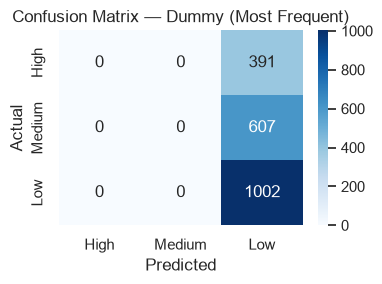


=== Logistic Regression ===
              precision    recall  f1-score   support

        High       0.00      0.00      0.00       391
         Low       0.50      1.00      0.67      1002
      Medium       0.00      0.00      0.00       607

    accuracy                           0.50      2000
   macro avg       0.17      0.33      0.22      2000
weighted avg       0.25      0.50      0.33      2000



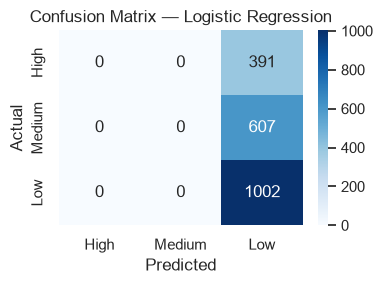


=== Decision Tree ===
              precision    recall  f1-score   support

        High       0.19      0.20      0.20       391
         Low       0.49      0.49      0.49      1002
      Medium       0.30      0.28      0.29       607

    accuracy                           0.37      2000
   macro avg       0.33      0.33      0.33      2000
weighted avg       0.37      0.37      0.37      2000



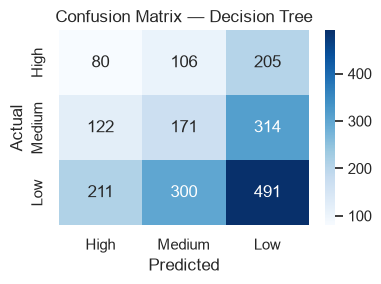


=== Random Forest ===
              precision    recall  f1-score   support

        High       0.50      0.01      0.02       391
         Low       0.50      0.96      0.66      1002
      Medium       0.35      0.05      0.09       607

    accuracy                           0.50      2000
   macro avg       0.45      0.34      0.25      2000
weighted avg       0.46      0.50      0.36      2000



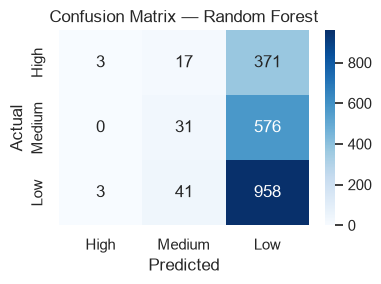


=== Random Forest (Tuned max_depth=8) ===
              precision    recall  f1-score   support

        High       0.00      0.00      0.00       391
         Low       0.50      1.00      0.67      1002
      Medium       0.00      0.00      0.00       607

    accuracy                           0.50      2000
   macro avg       0.17      0.33      0.22      2000
weighted avg       0.25      0.50      0.33      2000



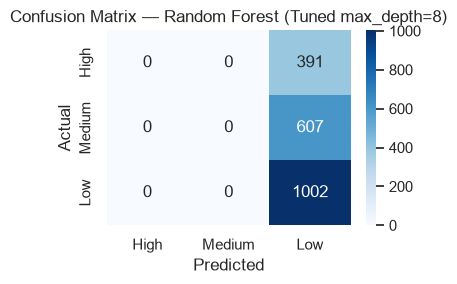

In [12]:
for item in results:
    print(f"\n=== {item['Model']} ===")
    print(item["Classification_Report"])

    plt.figure(figsize=(4, 3))
    sns.heatmap(
        item["Confusion_Matrix"],
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["High", "Medium", "Low"],
        yticklabels=["High", "Medium", "Low"],
    )
    plt.title(f"Confusion Matrix — {item['Model']}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()


In [13]:
best_model_name = metrics_df.loc[0, "Model"]
baseline_row = metrics_df[metrics_df["Model"] == "Dummy (Most Frequent)"].iloc[0]
best_row = metrics_df.iloc[0]

print(f"Best model by Macro-F1: {best_model_name}")
print(f"Best Macro-F1: {best_row['Macro_F1']:.4f} | Baseline Macro-F1: {baseline_row['Macro_F1']:.4f}")
print(f"Best High-class recall: {best_row['High_Recall']:.4f}")


Best model by Macro-F1: Decision Tree
Best Macro-F1: 0.3253 | Baseline Macro-F1: 0.2225
Best High-class recall: 0.2046


**Takeaway:** Results are compared directly against a majority-class baseline, with macro-F1 and High-risk recall treated as primary decision metrics.


## Phase 7 — Prediction output and recommendations


In [14]:
best_model = fitted_models[best_model_name]

weakness_columns = [
    "Attendance (%)",
    "Midterm_Score",
    "Assignments_Avg",
    "Quizzes_Avg",
    "Participation_Score",
    "Projects_Score",
    "math_score",
    "reading_score",
    "writing_score",
    "science_score",
]

def get_weakest_factor(row):
    available = {k: row[k] for k in weakness_columns if pd.notna(row[k])}
    if not available:
        return "General"
    return min(available, key=available.get)

def build_recommendation(risk_label, weakest_factor):
    if risk_label == "High":
        if weakest_factor == "Attendance (%)":
            return "Immediate attendance recovery plan with mentor check-ins twice a week."
        return f"Targeted remediation in {weakest_factor} with weekly tutoring and practice sets."
    if risk_label == "Medium":
        if weakest_factor == "Attendance (%)":
            return "Stabilize attendance and track weekly completion goals."
        return f"Reinforce {weakest_factor} through revision schedules and short quizzes."
    if weakest_factor == "Attendance (%)":
        return "Performance is strong; maintain consistency by avoiding attendance drops."
    return f"Keep current momentum and sharpen {weakest_factor} for further improvement."

def predict_risk(student):
    if isinstance(student, (int, str)):
        student_row = df.loc[df["Student_ID"].astype(str) == str(student)].iloc[0]
    else:
        student_row = student

    student_features = pd.DataFrame([student_row[feature_cols]])
    predicted_risk = best_model.predict(student_features)[0]
    weakest_factor = get_weakest_factor(student_row)
    recommendation = build_recommendation(predicted_risk, weakest_factor)

    student_name = f"{student_row['First_Name']} {student_row['Last_Name']}"
    attendance = student_row["Attendance (%)"]
    marks = student_row["Total_Score"]

    print(f"Student: {student_name} ({student_row['Student_ID']})")
    print(f"Attendance: {attendance}")
    print(f"Marks: {marks}")
    print(f"Risk: {predicted_risk}")
    print(f"Recommendation: {recommendation}")

    return predicted_risk, recommendation

prediction_df = df.copy()
prediction_df["Predicted_Risk"] = best_model.predict(prediction_df[feature_cols])
prediction_df["Weakest_Factor"] = prediction_df.apply(get_weakest_factor, axis=1)
prediction_df["Recommendation"] = prediction_df.apply(
    lambda row: build_recommendation(row["Predicted_Risk"], row["Weakest_Factor"]),
    axis=1,
)

prediction_df["Student"] = prediction_df["First_Name"].astype(str) + " " + prediction_df["Last_Name"].astype(str)
report_df = prediction_df[["Student", "Attendance (%)", "Predicted_Risk", "Recommendation"]].rename(
    columns={"Predicted_Risk": "Risk"}
)

report_path = "student_risk_recommendations.csv"
report_df.to_csv(report_path, index=False)
print(f"Saved bonus recommendation report to: {report_path}")

# Example call
predict_risk(prediction_df.iloc[0])


Saved bonus recommendation report to: student_risk_recommendations.csv
Student: Omar Williams (S1000)
Attendance: 52.29
Marks: 56.09
Risk: High
Recommendation: Targeted remediation in Participation_Score with weekly tutoring and practice sets.


('High',
 'Targeted remediation in Participation_Score with weekly tutoring and practice sets.')

**Takeaway:** The notebook now provides student-level risk prediction output in the required format and produces a full recommendation CSV for all students.
